In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("ushape.csv")

In [3]:
df.head()

,X,Y,class
0,0.031595,0.986988,0.0
1,2.115098,-0.046244,1.0
2,0.882490,-0.075756,0.0
3,-0.055144,-0.037332,1.0
4,0.829545,-0.539321,1.0


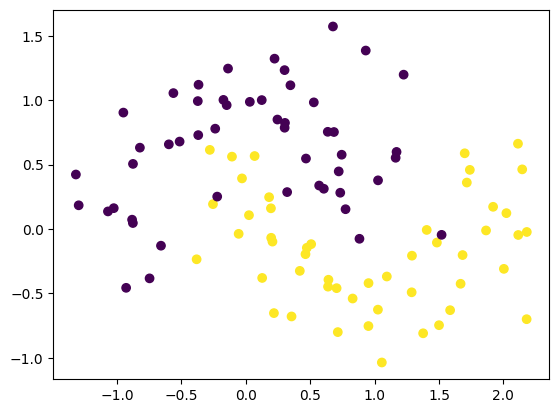

In [4]:
plt.scatter(df['X'],df['Y'],c=df['class'])

In [5]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

In [6]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [10]:
model = Sequential()
model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.get_weights()

[array([[ 1.229432  ,  1.6337492 ,  0.0262989 , -1.4309174 , -1.660472  ,
          1.0456052 ,  1.3133633 ,  0.7613619 , -2.03996   ,  1.1977925 ],
        [-0.9134279 ,  0.93946785, -1.9912337 ,  1.5632225 , -0.05611253,
          2.01575   ,  0.70625013, -0.07473473, -1.6464436 ,  0.9689374 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.4252315 ,  0.49057984, -0.31373525,  0.05095615, -0.03915183,
          0.03199067,  1.0093317 , -0.22521928,  0.45692247,  0.21789883],
        [-0.07627273, -0.5468259 ,  0.23731445,  0.41831195, -0.98726535,
         -0.24531704, -0.06706151,  0.50167584, -0.05799079, -0.06203369],
        [-0.4258314 ,  0.5770844 ,  0.6212068 ,  0.12461375,  0.31322116,
         -0.69536257,  0.67275894, -0.72944665, -0.5461465 , -0.54588234],
        [-0.01812438, -0.9815361 ,  0.25787738,  0.07209865,  0.72549796,
         -0.5910737 ,  0.89019626, -0.37073034, -0.04239665, -0.5671427 ],
        [-0.06429

In [12]:
initial_weights = model.get_weights()

In [13]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(2/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(2/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(2/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(2/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(2/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [14]:
model.set_weights(initial_weights)

In [15]:
model.get_weights()

[array([[ 0.07777739, -2.040067  , -1.5795041 , -1.695473  ,  0.09789963,
          0.5061662 , -1.6954356 ,  0.7360695 ,  2.6070752 ,  1.9731512 ],
        [-1.67535   , -0.4155799 , -1.5046488 , -0.69345367,  1.015972  ,
          0.45190564, -1.7030901 ,  0.5235065 , -1.4183949 , -0.12948336]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.42030483, -0.37259197, -0.11152969,  0.2374639 , -0.10710711,
         -0.74102485, -0.61277604, -0.04322812, -0.37720773,  0.47669405],
        [-0.84825104, -0.30689514, -0.9608693 , -0.30101678,  0.1598589 ,
         -0.28097287, -0.4724598 , -0.0336647 ,  0.37950665,  0.28896454],
        [-0.09534735,  0.24624668, -0.06939095,  0.51954836, -0.22031276,
         -0.10560701,  0.7286922 ,  0.73097265, -1.5129453 , -0.03221054],
        [-0.59986824, -0.26306567, -1.0115844 ,  0.1106968 ,  0.17680025,
         -0.3297777 , -0.03592866,  0.49372372,  0.4968834 ,  0.5363113 ],
        [ 1.10018

In [16]:
model.compile(loss='binary_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [17]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step - accuracy: 0.4000 - loss: 0.7934 - val_accuracy: 0.4500 - val_loss: 0.6908
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4000 - loss: 0.7685 - val_accuracy: 0.4500 - val_loss: 0.6677
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.4250 - loss: 0.7485 - val_accuracy: 0.4500 - val_loss: 0.6471
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4250 - loss: 0.7287 - val_accuracy: 0.5000 - val_loss: 0.6288
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4500 - loss: 0.7130 - val_accuracy: 0.5000 - val_loss: 0.6116
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.4625 - loss: 0.6977 - val_accuracy: 0.5000 - val_loss: 0.5965
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5375 - loss: 0.6839 - val_accuracy: 0.5500 - val_loss: 0.5824
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5250 - loss: 0.6720 - val_accuracy: 0.6500 - val_loss:

In [18]:
model.get_weights()

[array([[ 0.14757569, -2.0993066 , -1.6814219 , -1.8143927 ,  0.1223278 ,
          0.5471783 , -1.7624633 ,  0.6646446 ,  2.4770582 ,  2.0776649 ],
        [-1.917286  , -0.35760632, -1.4091396 , -0.6169628 ,  1.0365237 ,
          0.36691132, -1.5730909 ,  0.68181145, -1.6190535 , -0.18853544]],
       dtype=float32),
 array([ 0.18083026, -0.01880453, -0.0087692 , -0.09414604, -0.17145051,
        -0.02327204, -0.1654324 ,  0.05389072, -0.25878015,  0.13445917],
       dtype=float32),
 array([[-0.42030483, -0.37259197, -0.11152969,  0.41889018, -0.16663939,
         -0.74102485, -0.61277604, -0.15648505, -0.37720773,  0.7174541 ],
        [-0.8535213 , -0.30689514, -0.94160646, -0.22729187,  0.2544016 ,
         -0.29388803, -0.4724598 ,  0.07626909,  0.4612339 ,  0.21796449],
        [-0.09534735,  0.24624668, -0.06939095,  0.64147437, -0.24345833,
         -0.10560701,  0.7286922 ,  0.73776233, -1.6338453 ,  0.02295509],
        [-0.6183861 , -0.26306567, -1.0115844 ,  0.18458398, 

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 7s 677us/step


<Axes: >

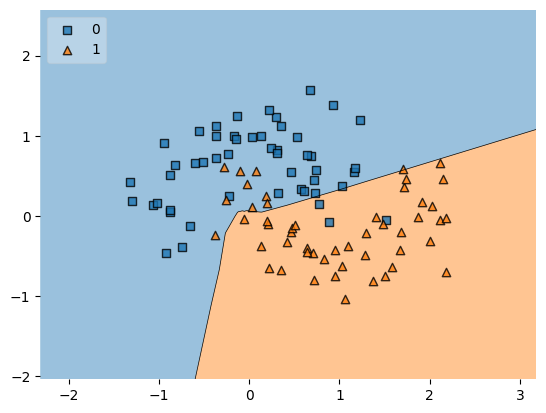

In [19]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X,y.astype('int'),clf=model,legend=2)